In [11]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.graphs.utils import *
from src.hyperbolicity.gromov import *
from src.graphs.visualization import *
from collections import Counter
%load_ext autoreload
%autoreload 2
from src.optimization.solver import max_gromov_entropic_distance_regularized
from src.optimization.solver import min_gromov_entropic_distance_regularized

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


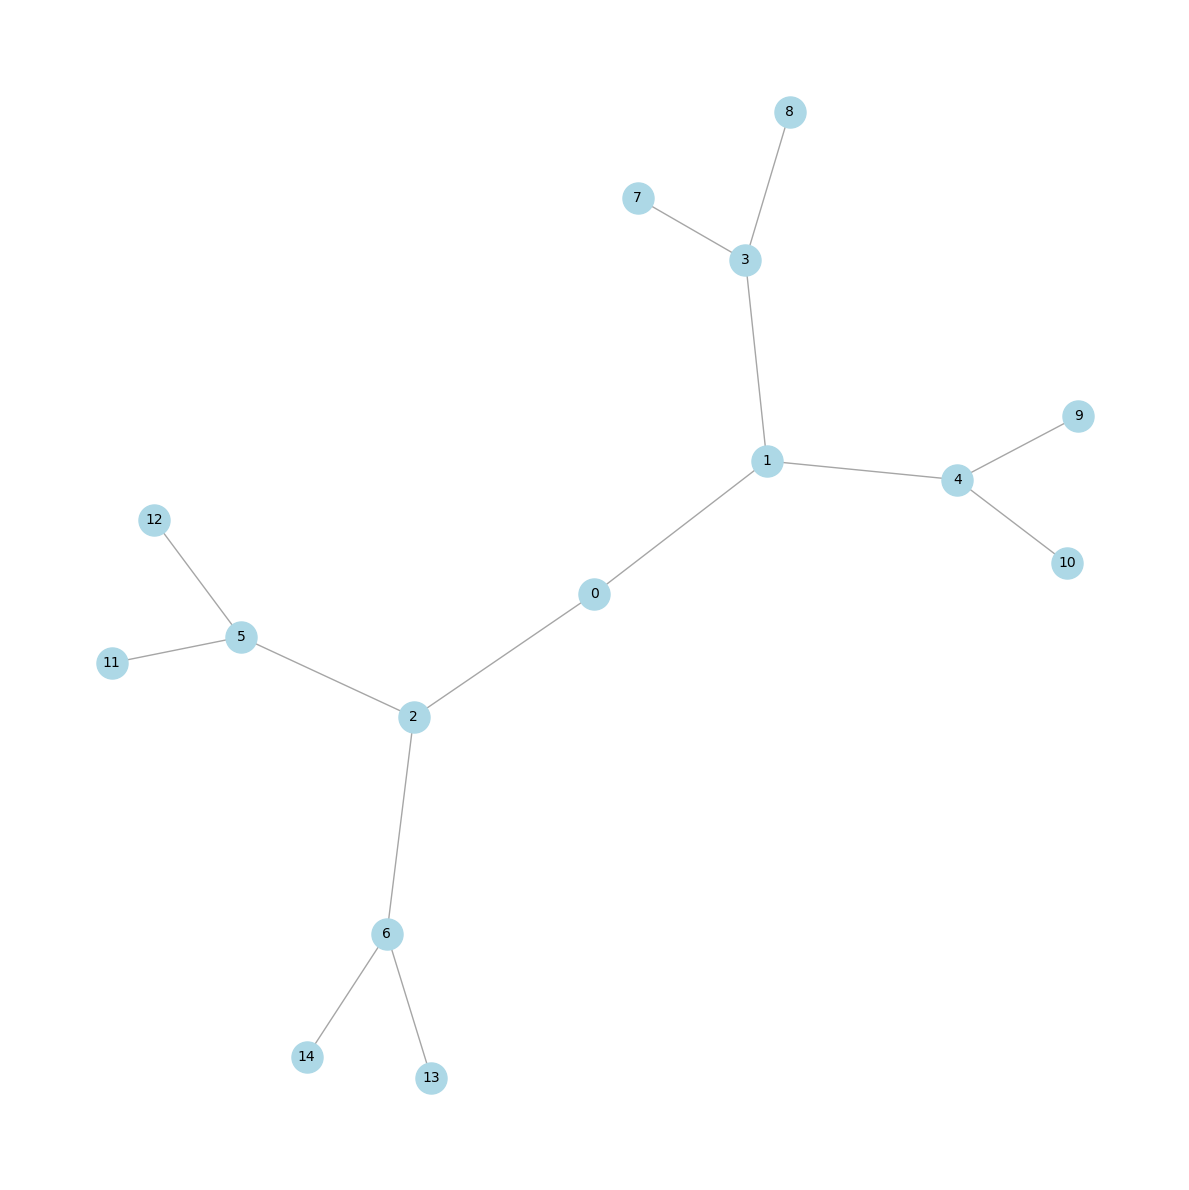

(<Figure size 1200x1200 with 1 Axes>, [<Axes: >])

In [21]:
G = nx.balanced_tree(r=2, h=3)
pos = draw_layout(G)
draw_graphs(G, pos, base_figsize=(12,12))

In [22]:
mu, quads = min_gromov_entropic_distance_regularized(G, lambda_reg = 0.5, T = 1)

In [23]:
# --- Risultati ---
top_idx = np.argsort(mu)[-5:][::-1]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

1365 combinations.
------------------------------
Tupla: (7, 10, 11, 14) | Peso mu: 0.000925
Tupla: (7, 10, 11, 13) | Peso mu: 0.000925
Tupla: (7, 10, 12, 13) | Peso mu: 0.000925
Tupla: (7, 10, 12, 14) | Peso mu: 0.000925
Tupla: (7, 9, 11, 14) | Peso mu: 0.000925
------------------------------
The sum of mu is 1.0000
Different values of mu are: 22


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Claudio\AppData\Local\Temp\ipykernel_26080\1586051503.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title("Distribution $\mu$")
C:\Users\Claudio\AppData\Local\Temp\ipykernel_26080\1586051503.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

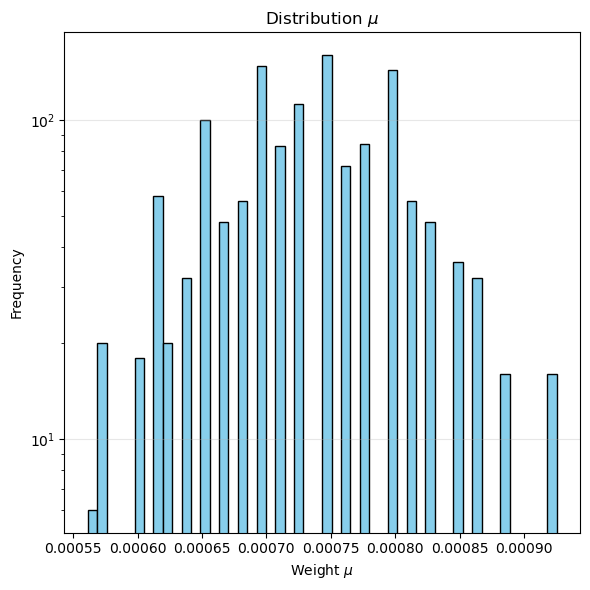

In [29]:
plt.figure(figsize=(6,6))
plt.hist(mu, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribution $\mu$")
plt.xlabel("Weight $\mu$")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

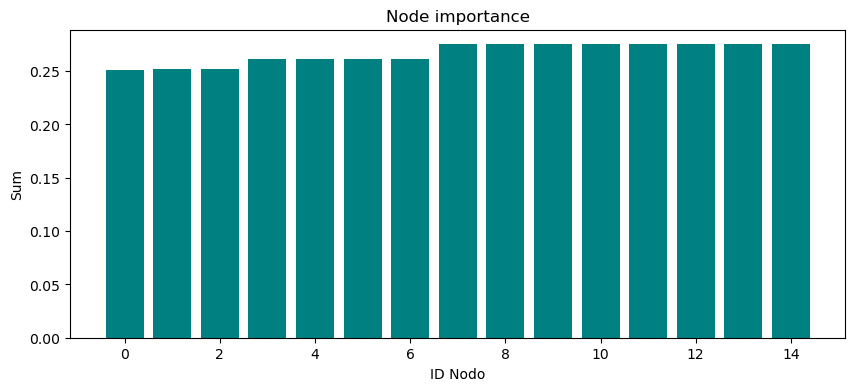

In [ ]:
node_importance = np.zeros(len(G.nodes()))
for i, q in enumerate(quads):
    for node in q:
        node_importance[node] += mu[i]

plt.figure(figsize=(10, 4))
plt.bar(range(len(node_importance)), node_importance, color='teal')
plt.title("Node importance")
plt.xlabel("ID Node")
plt.ylabel("Sum")
plt.show()

In [26]:
print(node_importance)

[0.25094608 0.25195823 0.25195823 0.26118514 0.26118514 0.26118514
 0.26118514 0.27504961 0.27504961 0.27504961 0.27504961 0.27504961
 0.27504961 0.27504961 0.27504961]
